In [16]:
%load_ext autoreload
%autoreload 2

In [1]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib
from dataclasses import dataclass
import seaborn as sns
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds as window_from_bounds
from rasterio.windows import Window

sns.set_theme()

In [2]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import GHANA_GDF, ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH, ETHZ_COCOA_MAP_FILEPATH, SILVER_FOLDERPATH, ETHZ_COCOA_MAP_UINT8_FILEPATH

In [3]:
# Load sites
sites = Site.load_all()
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


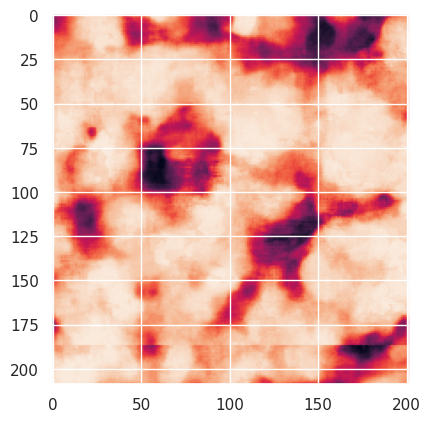

In [7]:
@dataclass
class CroppedETHZMap:
    probs: np.ndarray  # [0;1]
    bounds: rasterio.coords.BoundingBox
    crs: rasterio.CRS

    @staticmethod
    def _load_crop(bbox_wgs84: tuple[float, float, float, float], padding_px: float):
        """Loads a subset of the ETHZ raster around a WGS84 bbox, with added padding in meters.

        Args:
            bbox_wgs84: Tuple of (min_lon, min_lat, max_lon, max_lat).
            padding_m: Padding to add in all directions, in meters.

        Returns:
            data: The cropped numpy array.
            transform: The affine transform for the new cropped image.
        """
        min_lon, min_lat, max_lon, max_lat = bbox_wgs84

        with rasterio.open(ETHZ_COCOA_MAP_FILEPATH) as src:
            # Project the WGS84 bbox into the raster's native CRS
            base_window = window_from_bounds(min_lon, min_lat, max_lon, max_lat, transform=src.transform)

            # Add padding in pixels to the window's dimensions and offsets
            padded_window = Window(
                col_off=base_window.col_off - padding_px,
                row_off=base_window.row_off - padding_px,
                width=base_window.width + (2 * padding_px),
                height=base_window.height + (2 * padding_px)
            )

            # Read the data within that window
            # boundless=True pads the array with fill_values if padded bbox extends beyond the actual edges of the raster image.
            data = src.read(1, window=padded_window, boundless=True, fill_value=src.nodata)

            transform = src.window_transform(padded_window)

        return data, transform

plt.imshow(CroppedETHZMap._load_crop(sites[0].bbox_wgs84, 100)[0])

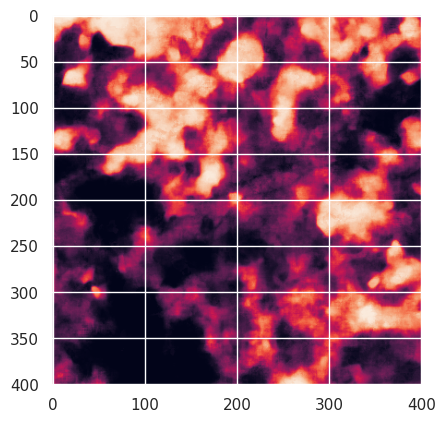

In [12]:
plt.imshow(CroppedETHZMap._load_crop(sites[3].bbox_wgs84, 200)[0])

In [21]:
def plot_site_over_ethz_map(site: Site, padding_px: int, ax = None):
    """Plot around the provided site"""
    if ax is None:
            ax = plt.gca()
        
    # Load cropped ETHZ map
    ethz_data, transform = CroppedETHZMap._load_crop(site.bbox_wgs84, padding_px)
    
    # Convert WGS84 (lon, lat) directly to pixel coordinates (col, row)
    lats = [lat for lat, _ in site.lat_lons]
    lons = [lon for _, lon in site.lat_lons]
    cols, rows = zip(*[~transform * (lon, lat) for lon, lat in zip(lons, lats)])
    
    # Plot
    ax.imshow(ethz_data, cmap="viridis", vmin=0.0, vmax=1.0)
    
    # Plot using the calculated pixel coordinates
    ax.scatter(cols, rows, color="red", marker="x", alpha=0.5, s=100, linewidths=2, label="Tree Location")
    
    ax.legend()
    ax.set_title(f"Site ({site.id}) | # trees: {len(site.trees)}\nETHZ Cocoa Map")


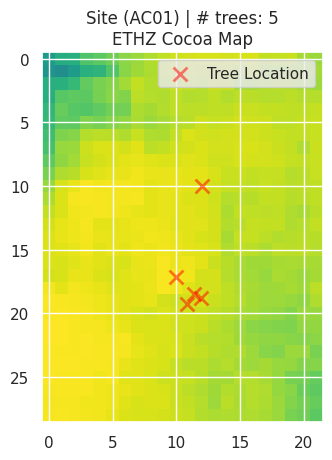

In [42]:
plot_site_over_ethz_map(sites[0], padding_px=10)

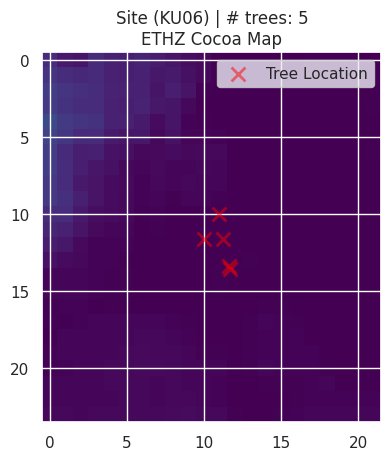

In [45]:
s = [e for e in sites if e.id == "KU06"][0]
plot_site_over_ethz_map(s, padding_px=10)

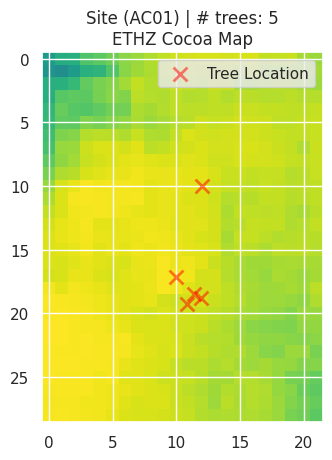

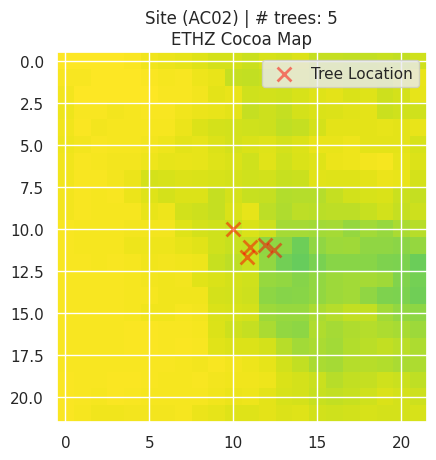

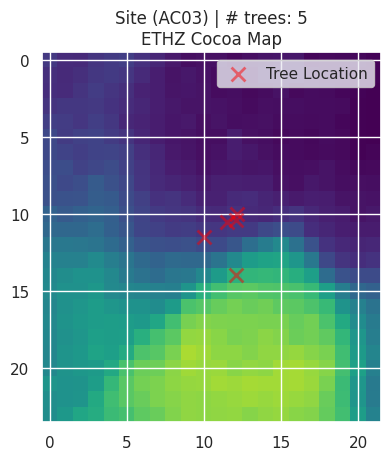

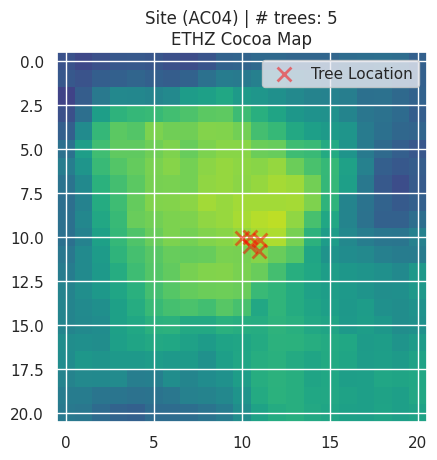

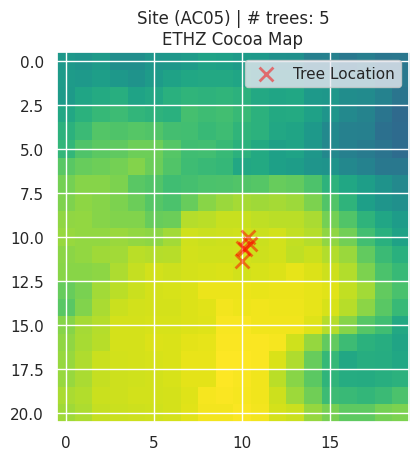

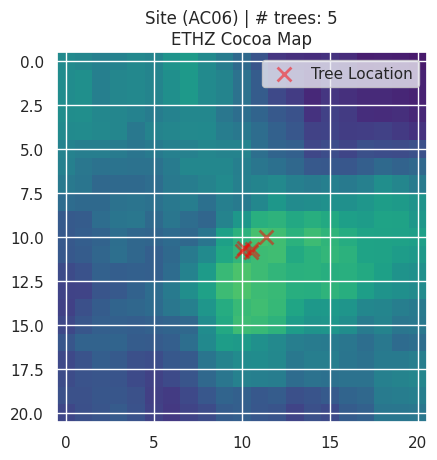

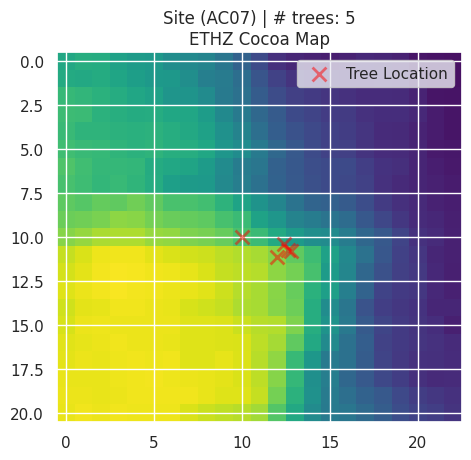

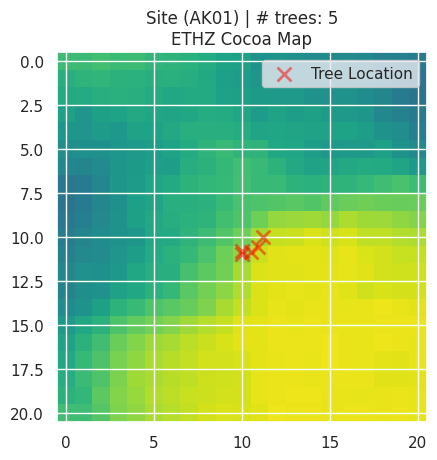

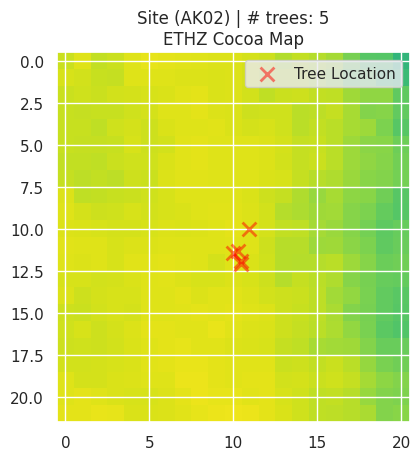

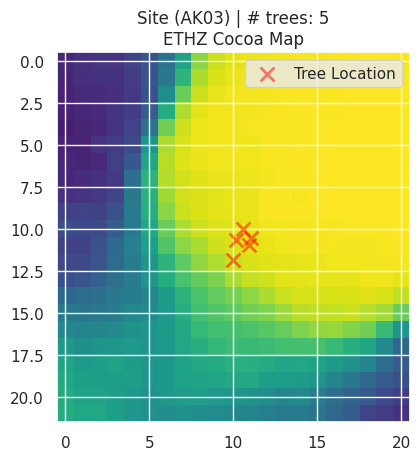

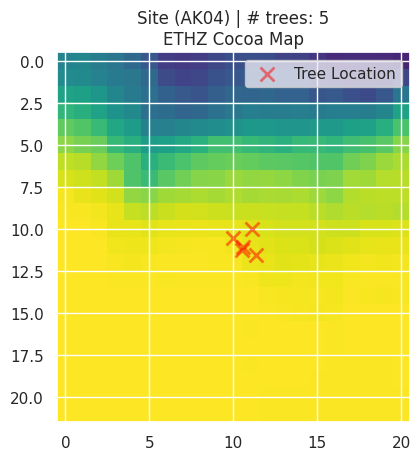

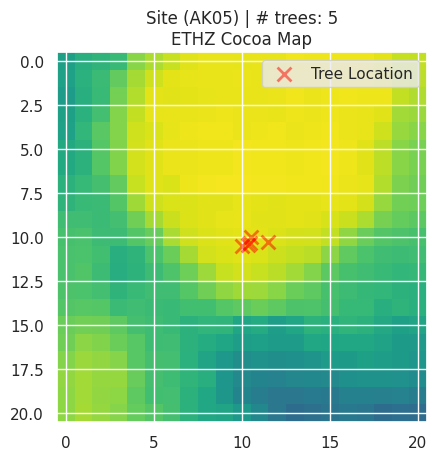

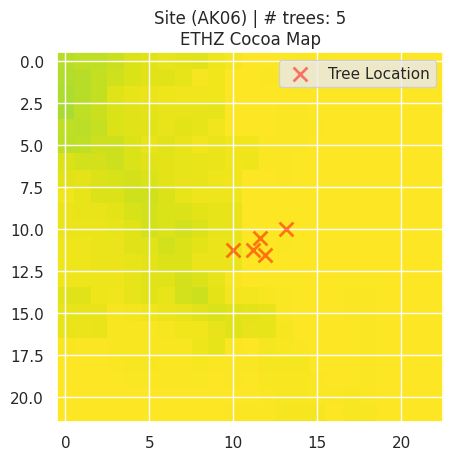

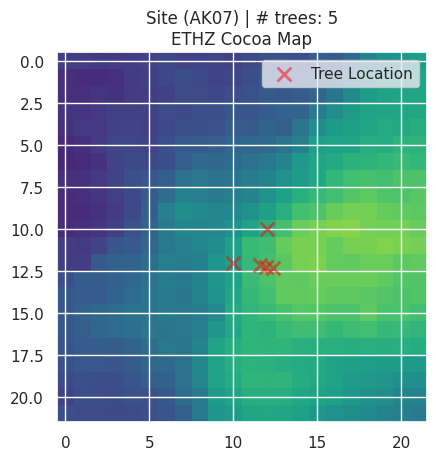

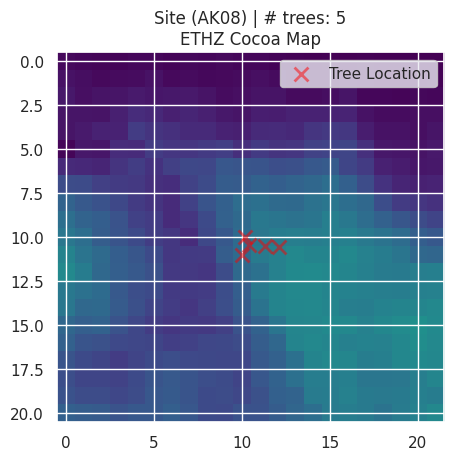

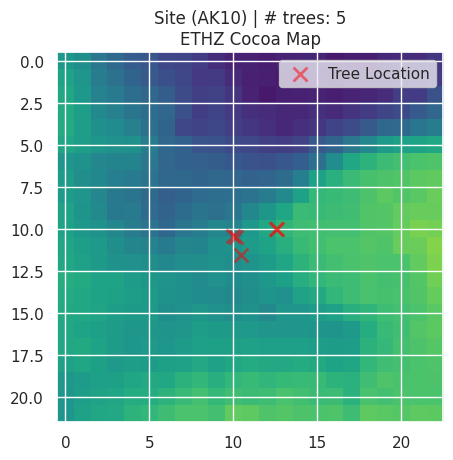

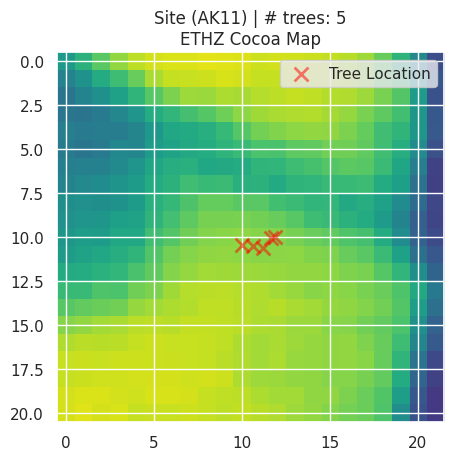

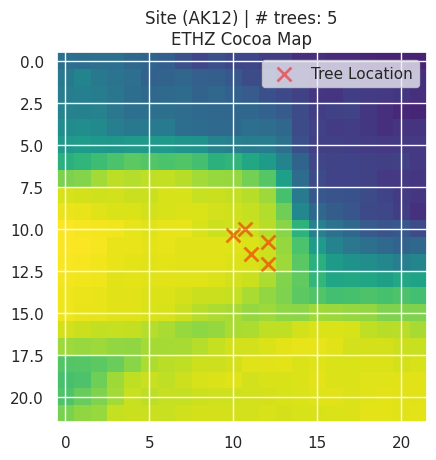

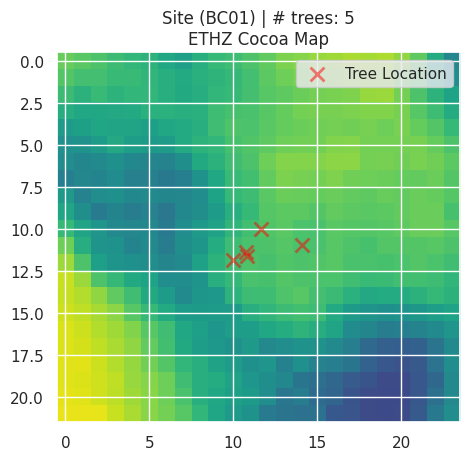

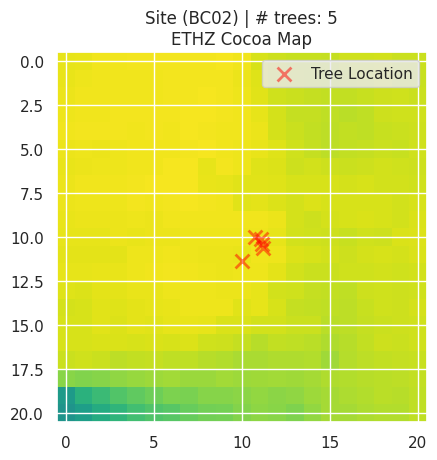

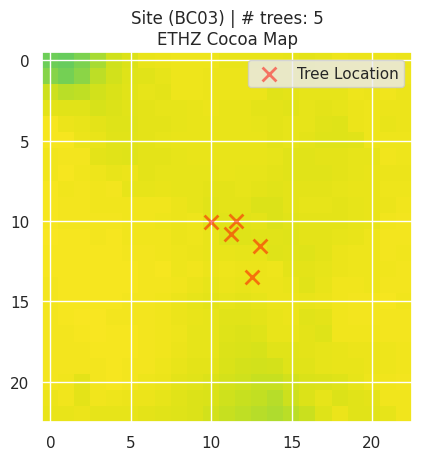

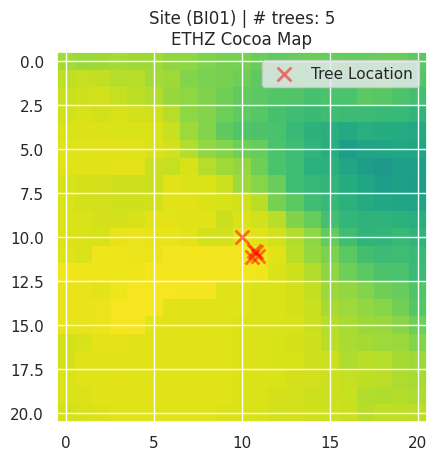

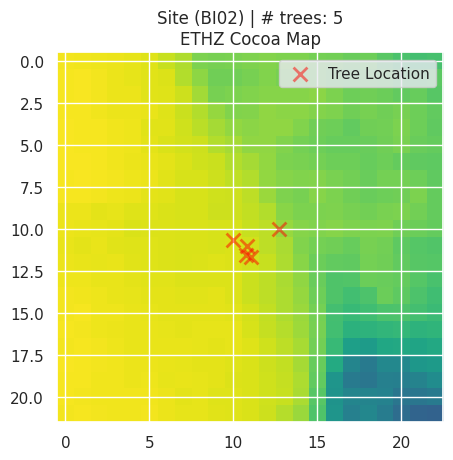

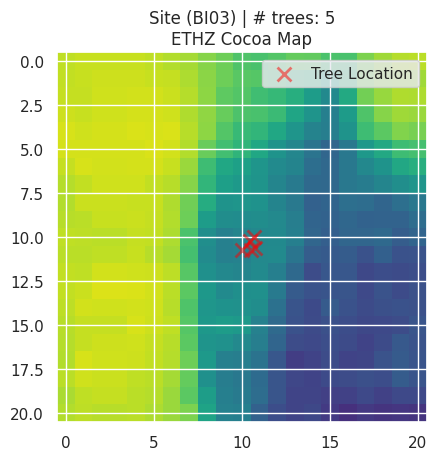

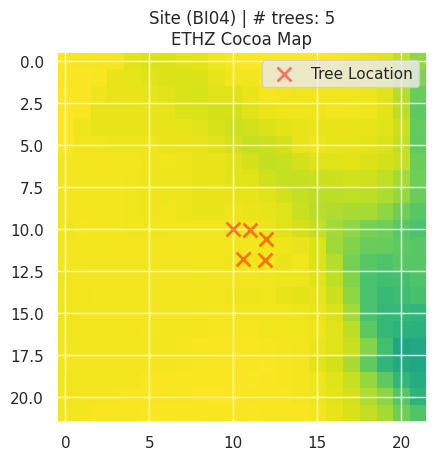

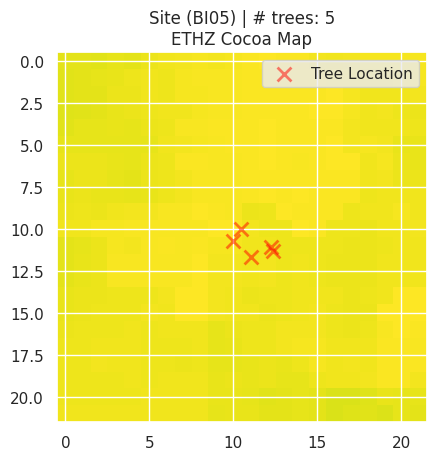

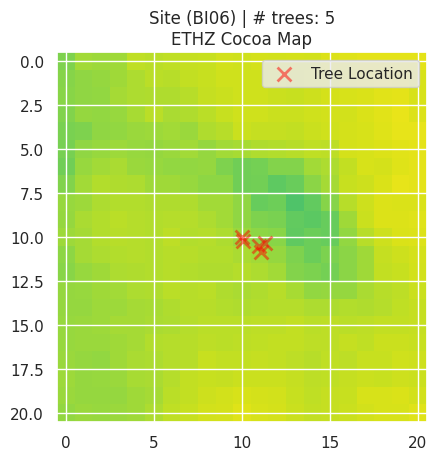

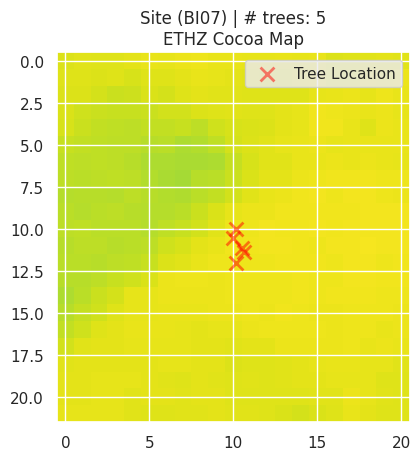

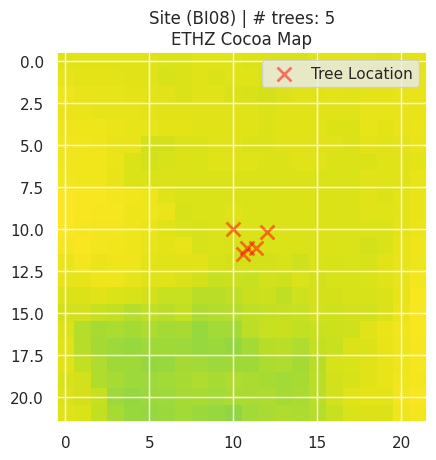

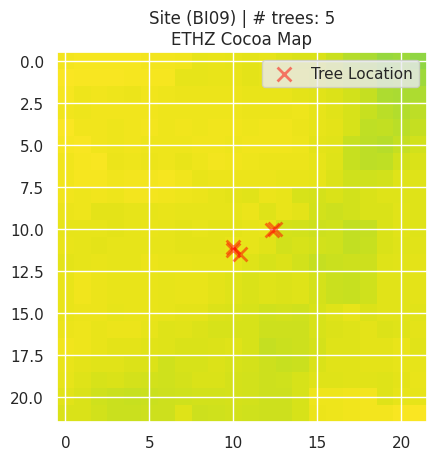

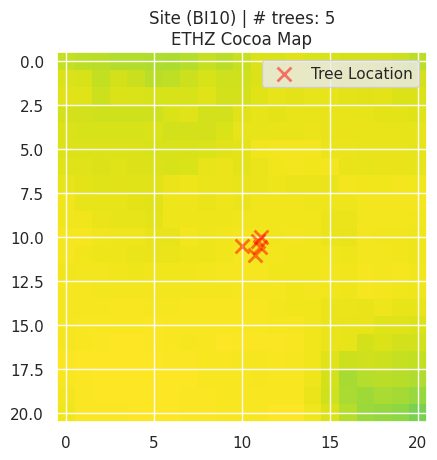

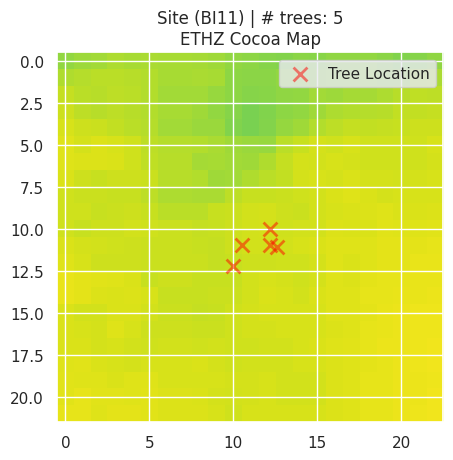

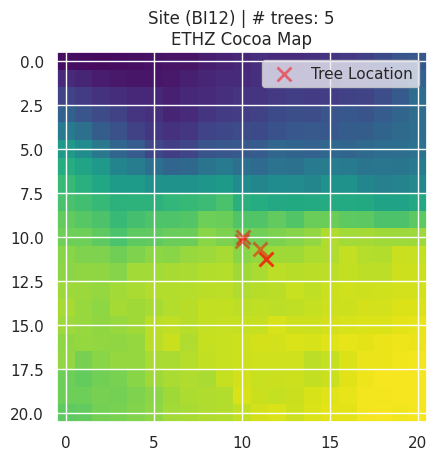

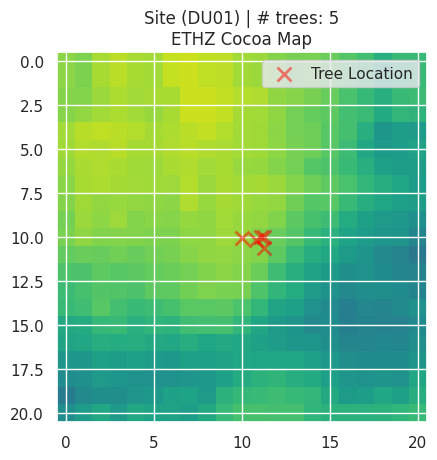

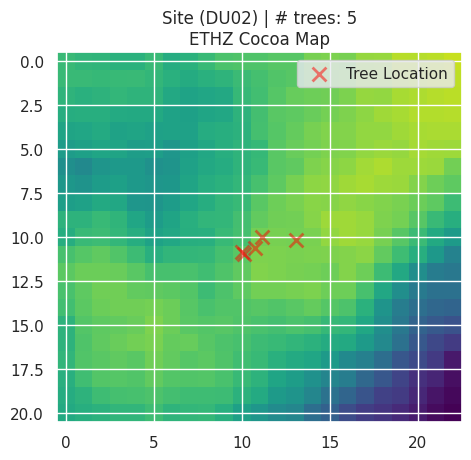

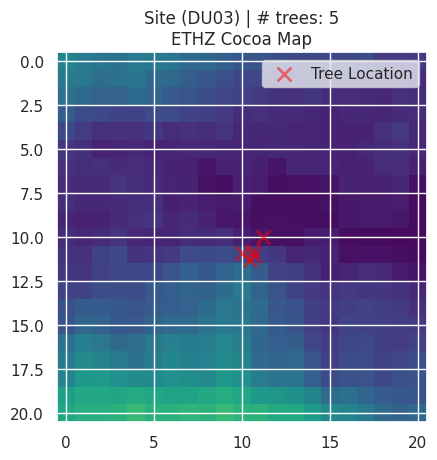

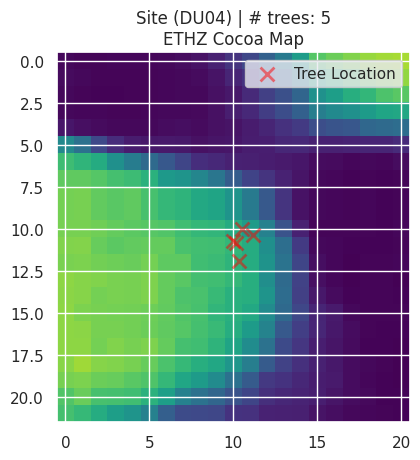

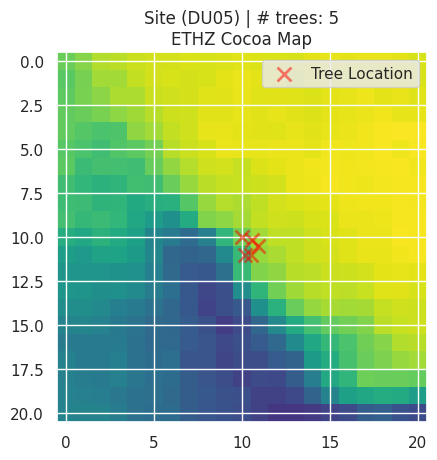

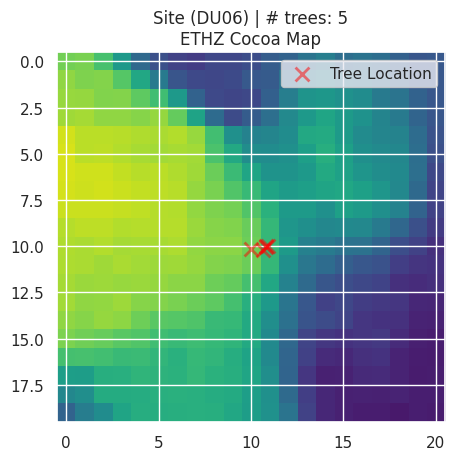

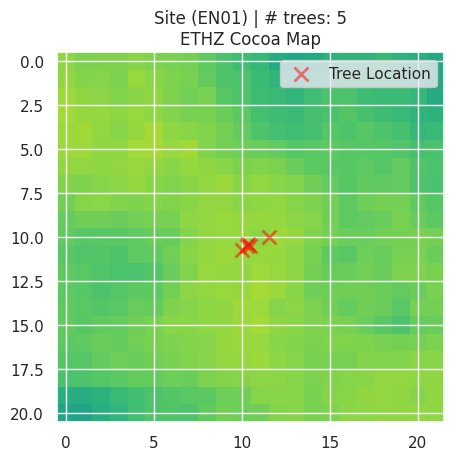

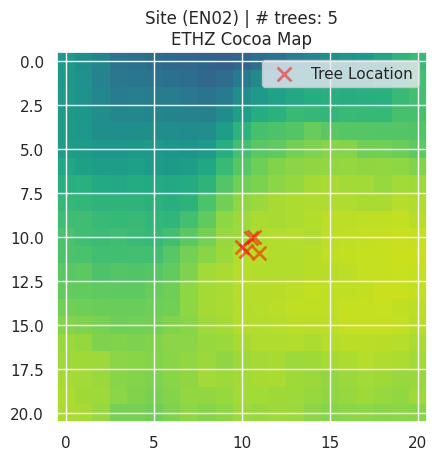

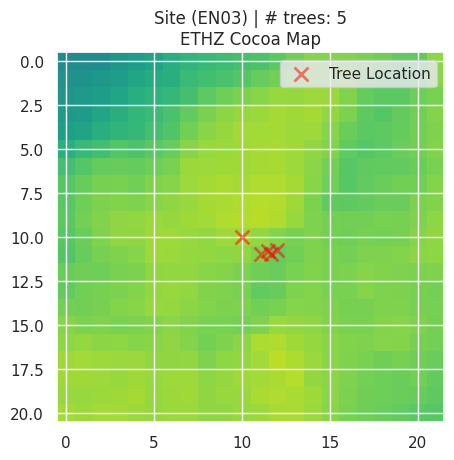

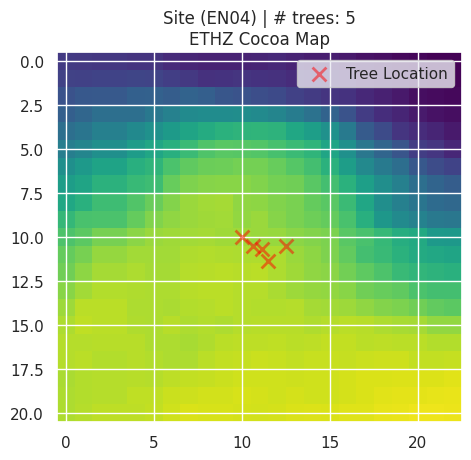

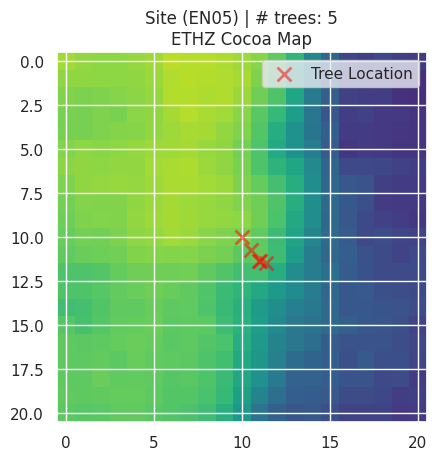

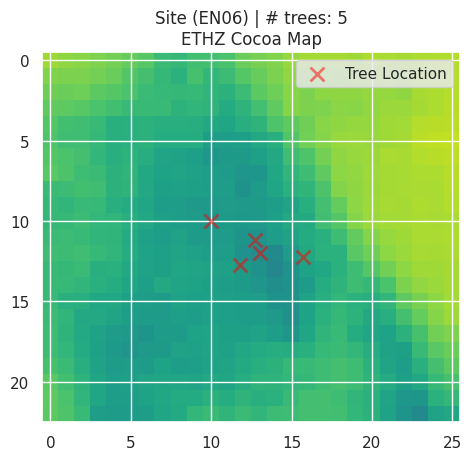

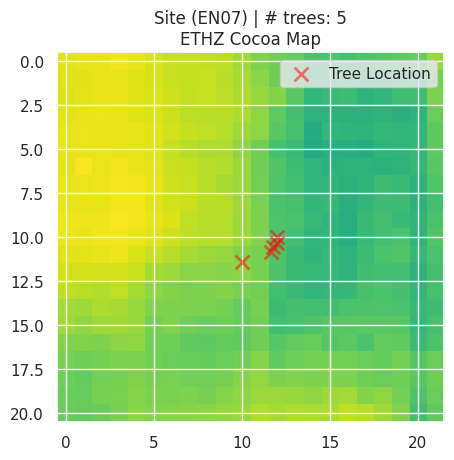

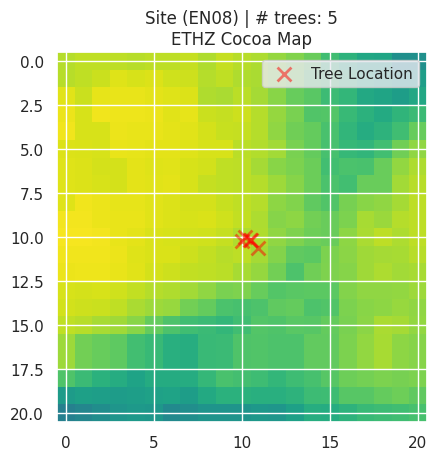

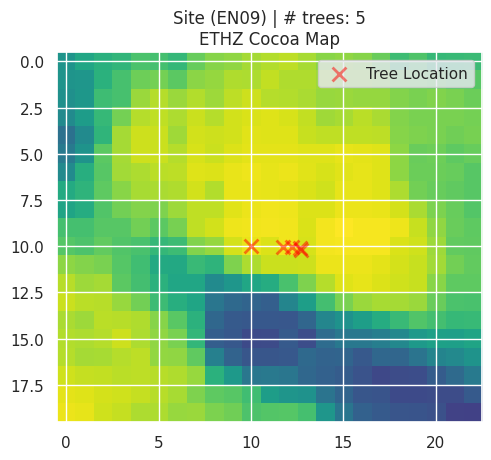

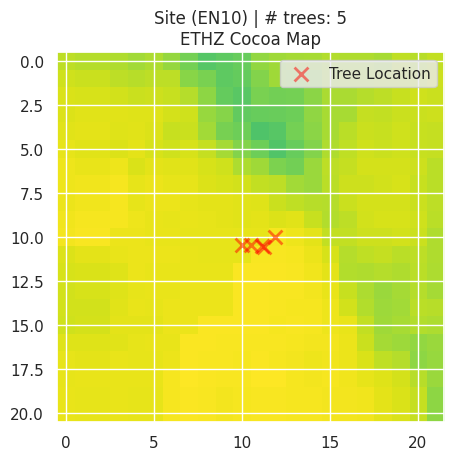

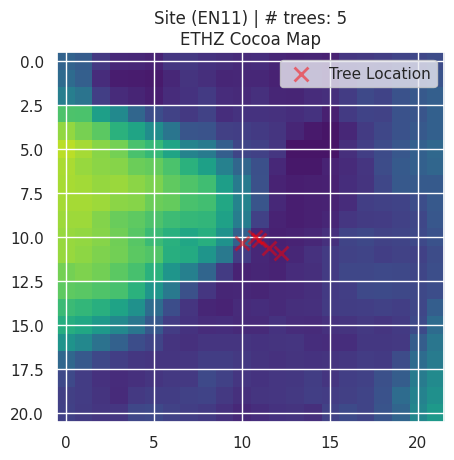

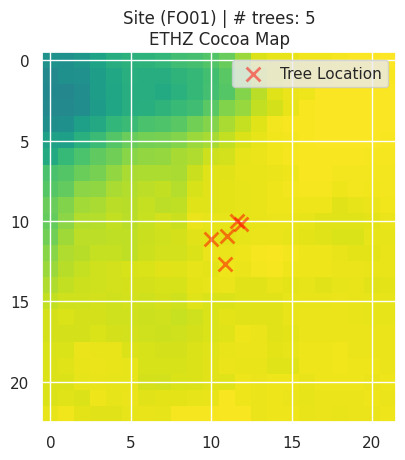

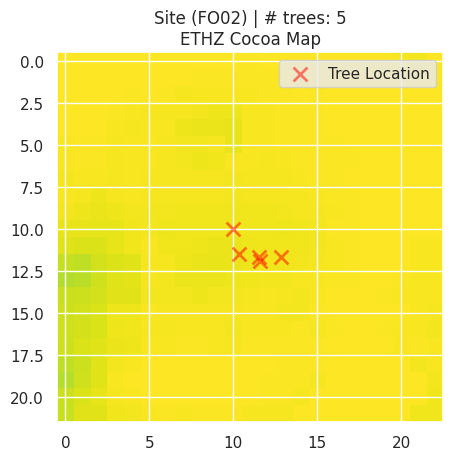

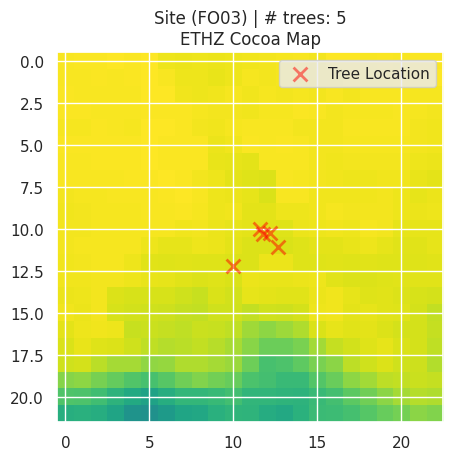

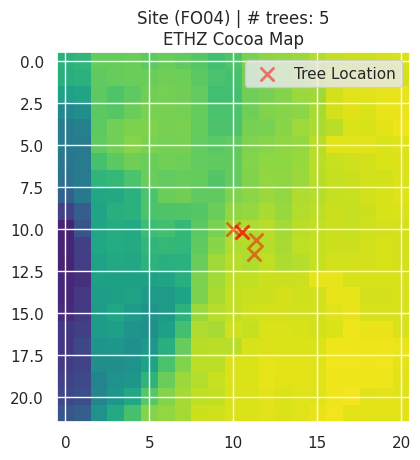

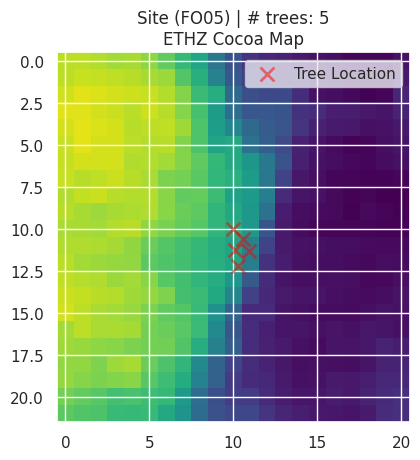

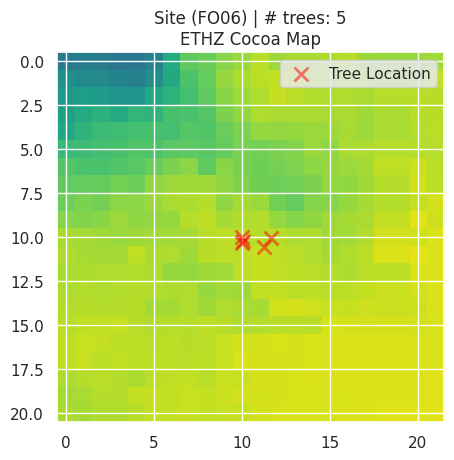

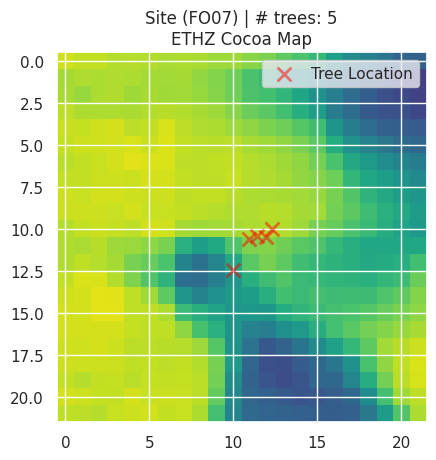

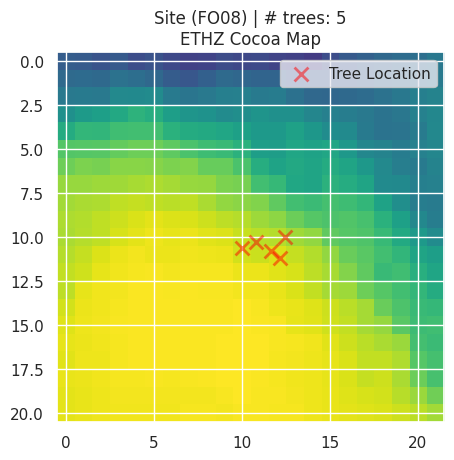

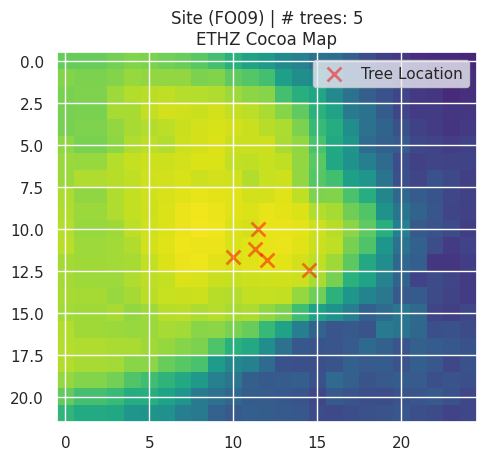

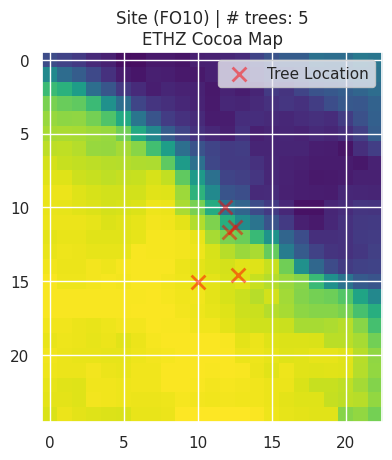

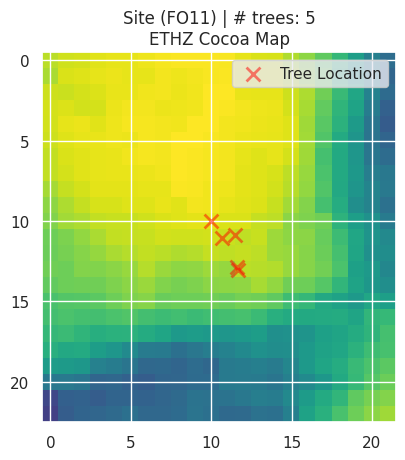

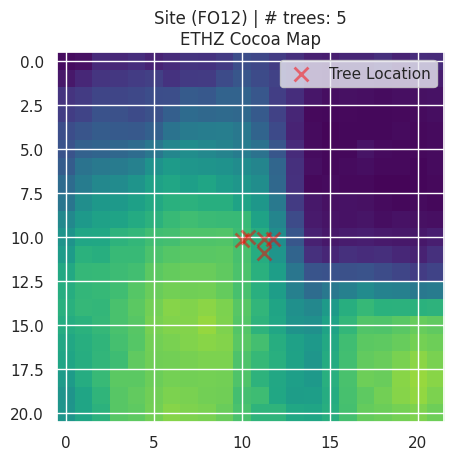

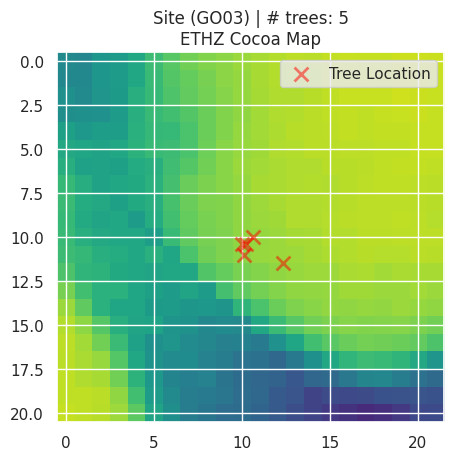

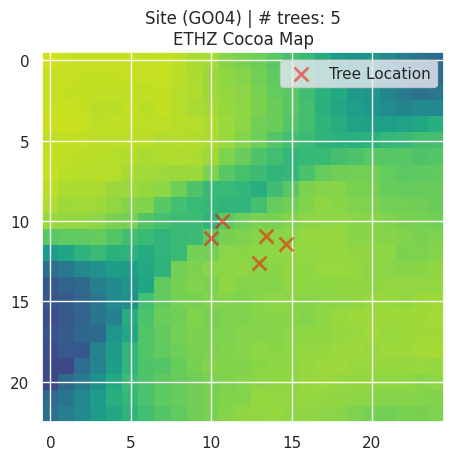

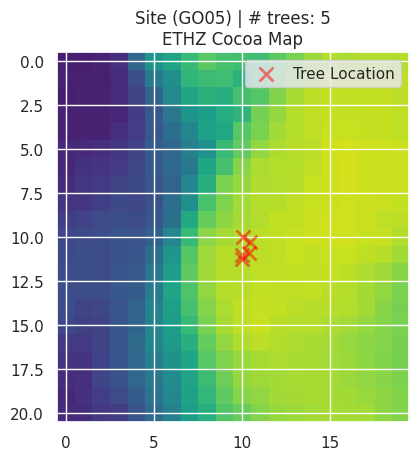

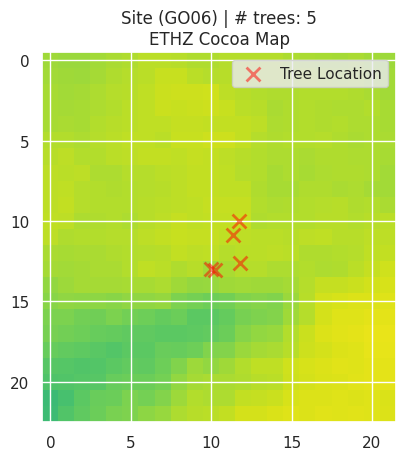

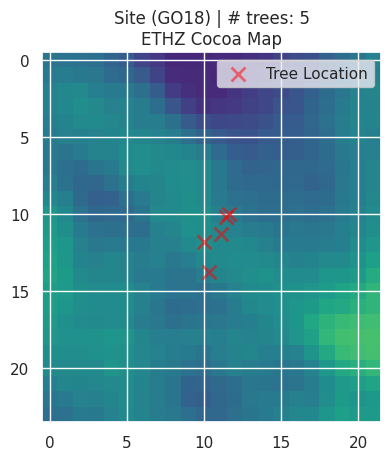

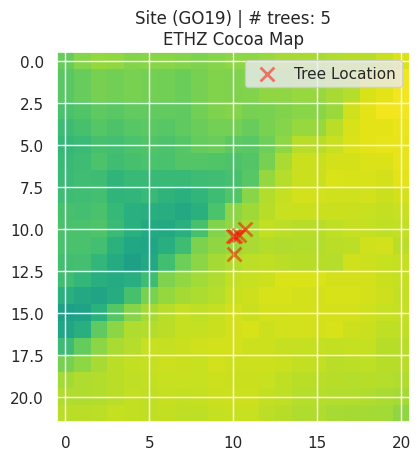

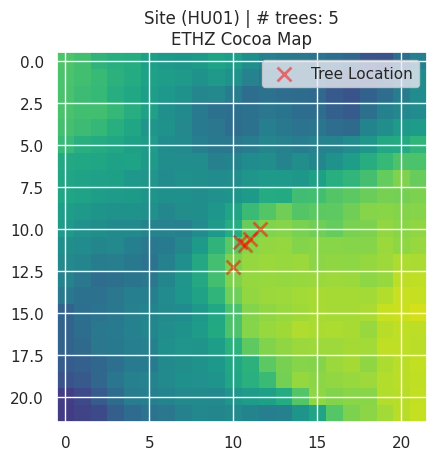

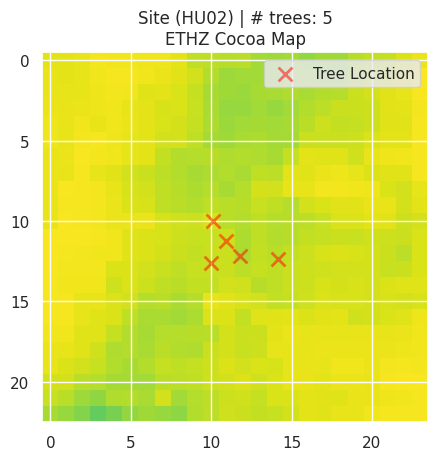

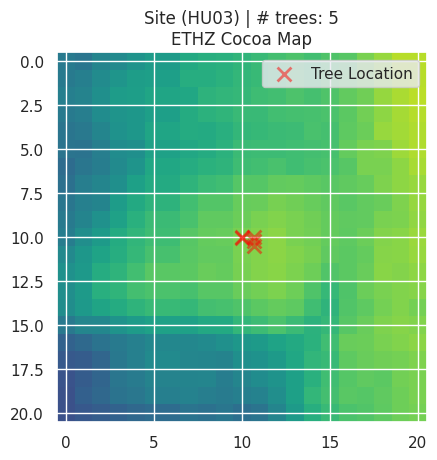

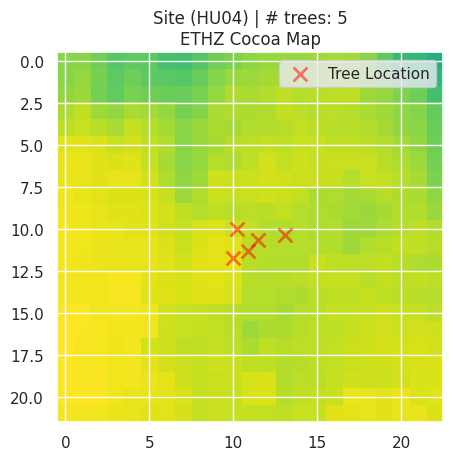

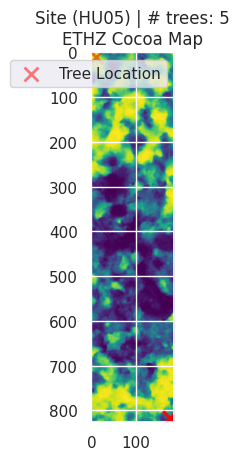

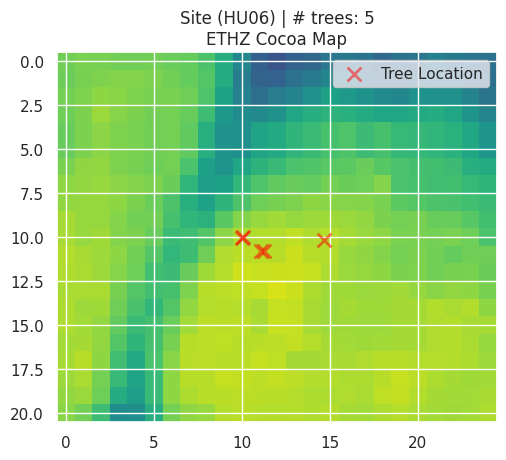

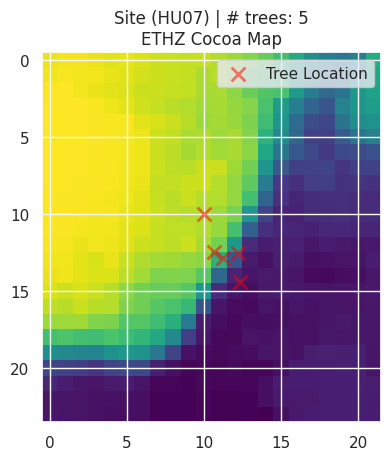

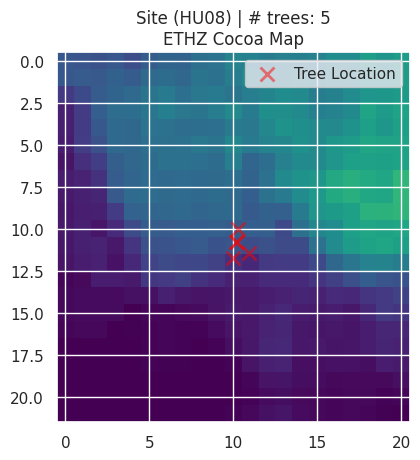

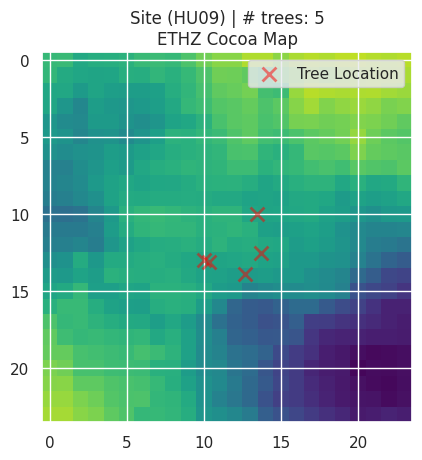

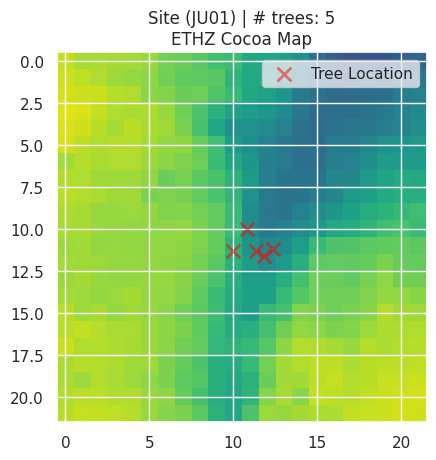

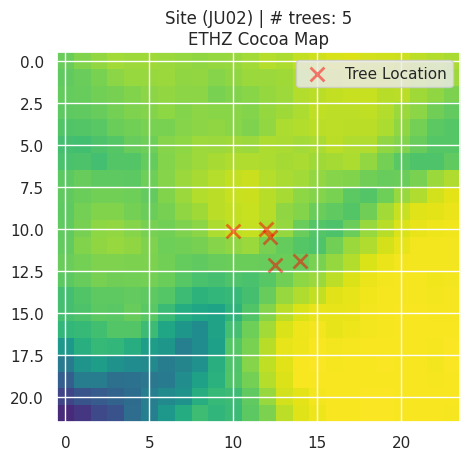

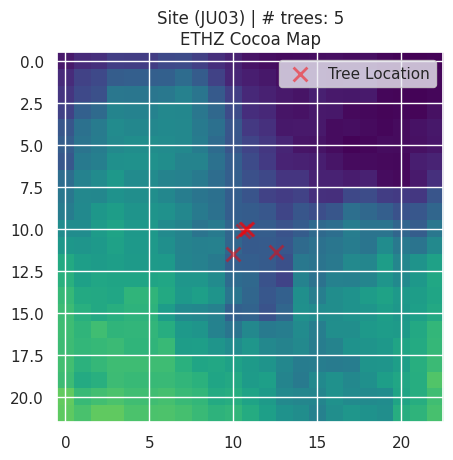

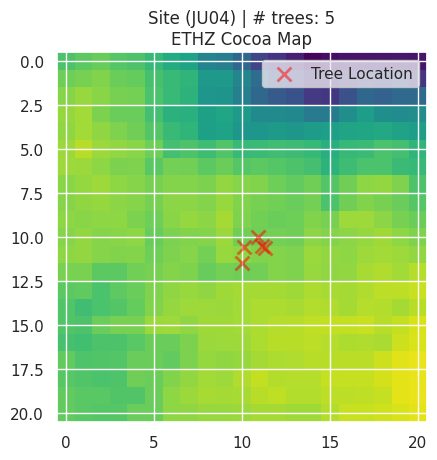

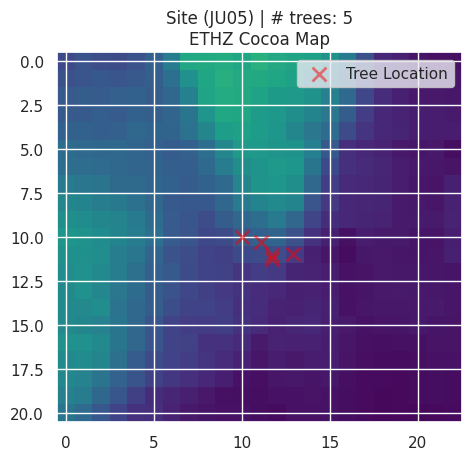

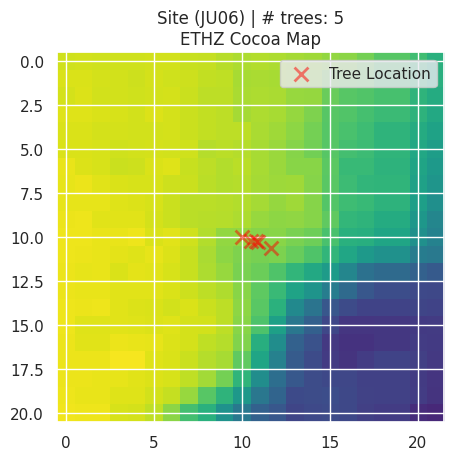

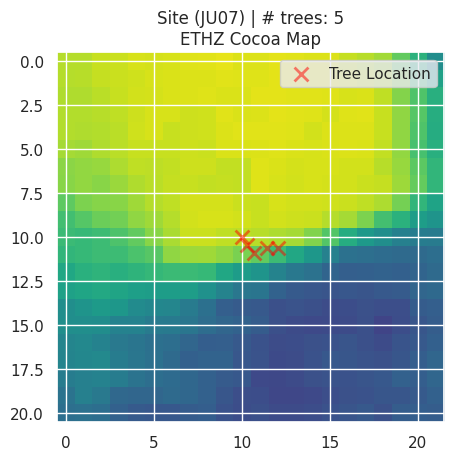

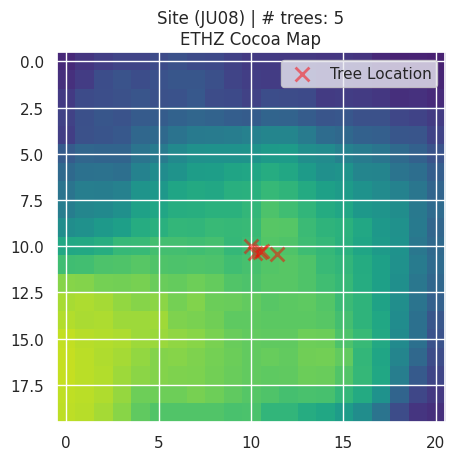

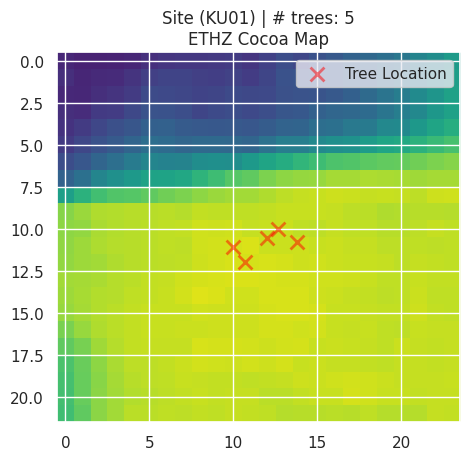

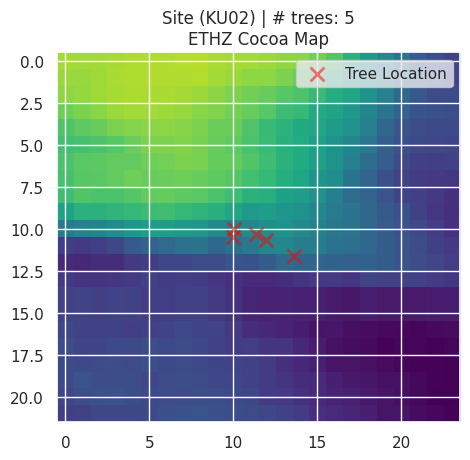

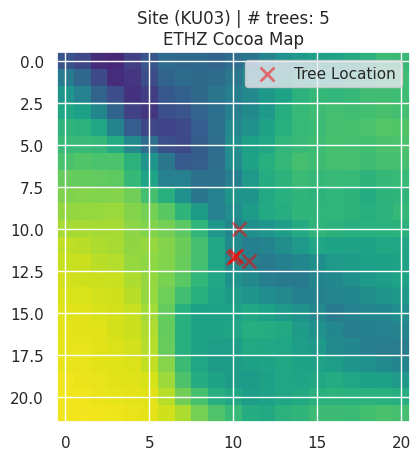

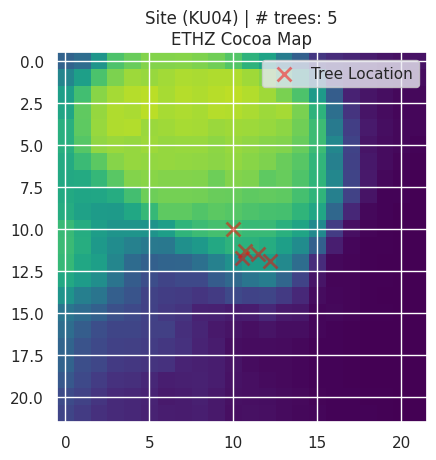

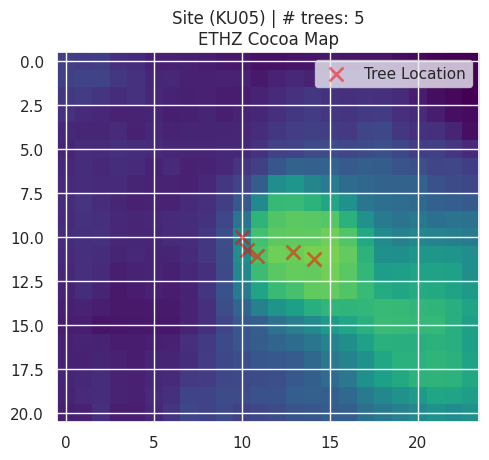

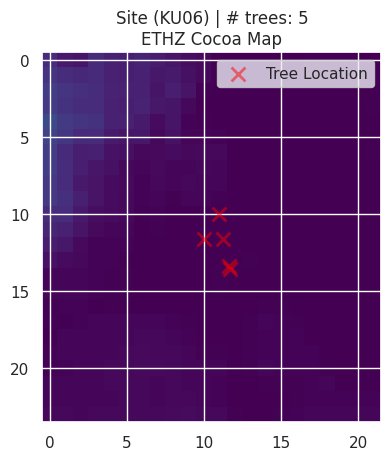

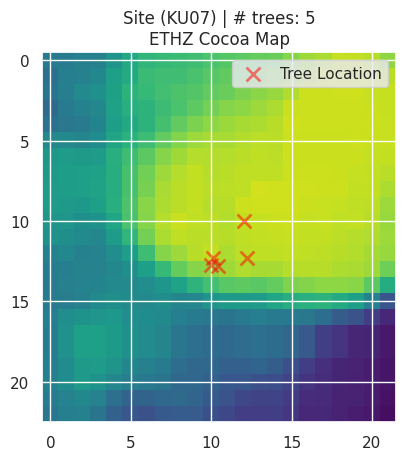

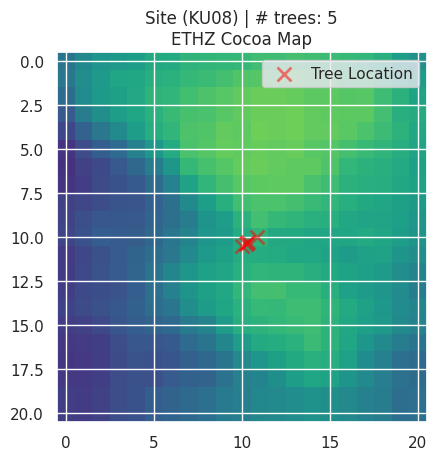

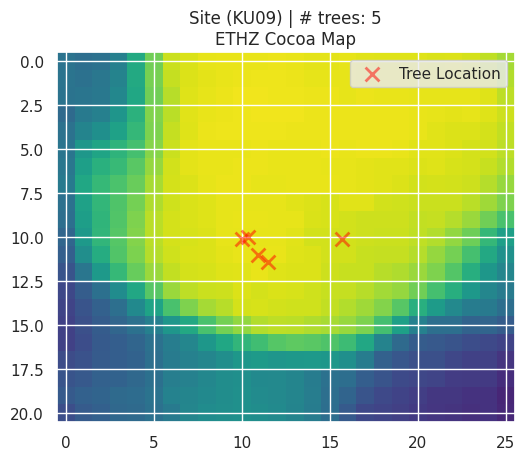

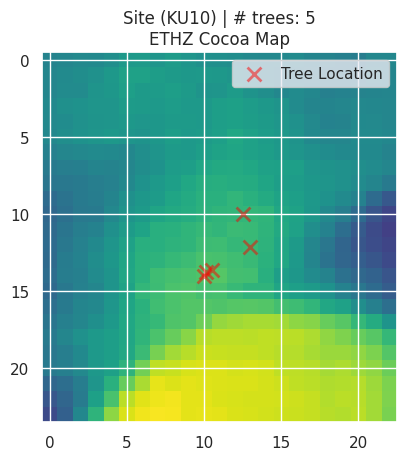

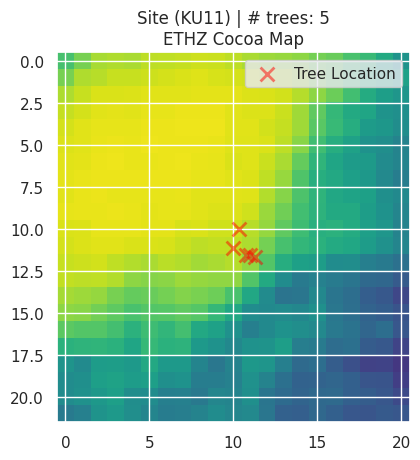

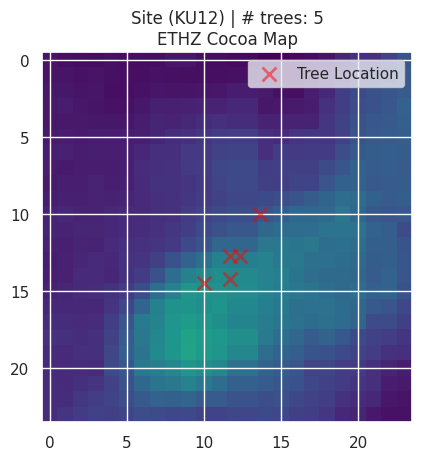

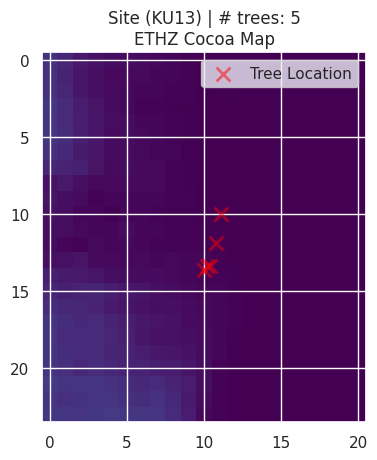

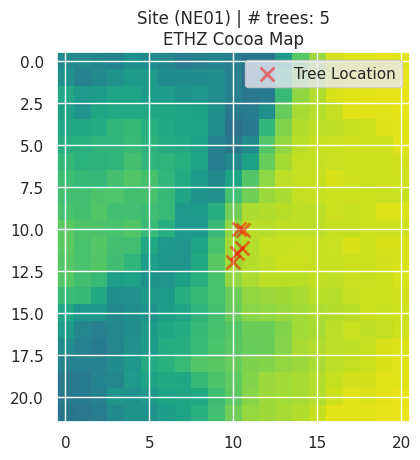

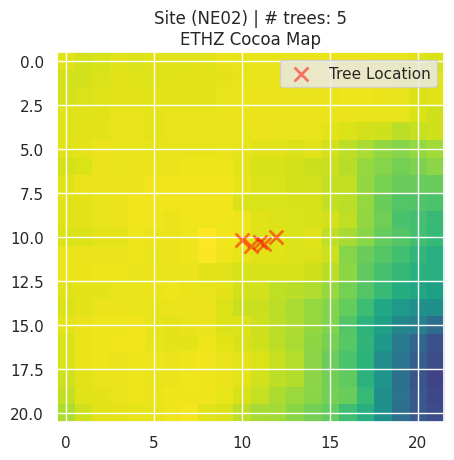

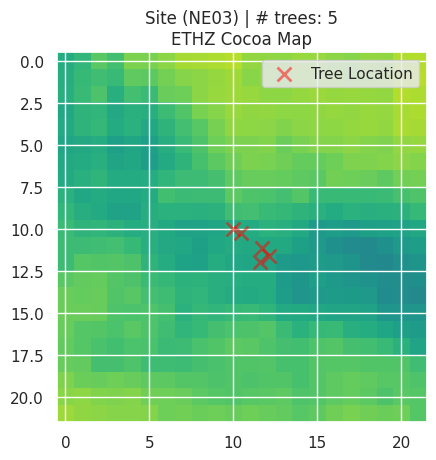

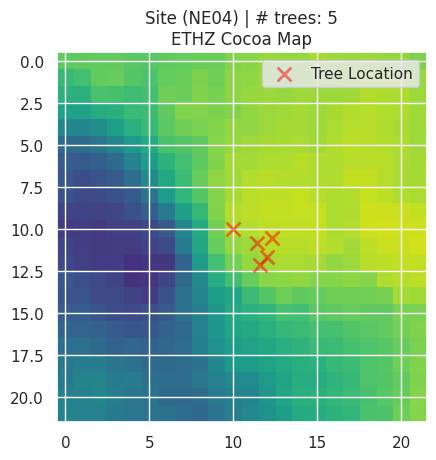

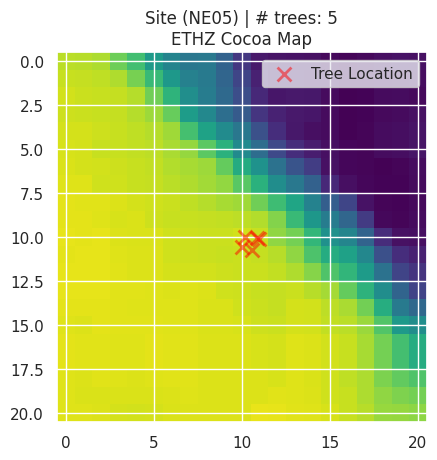

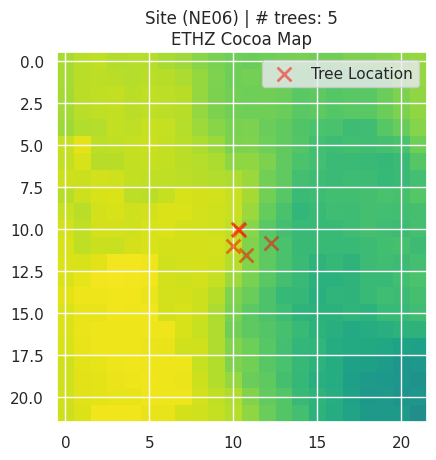

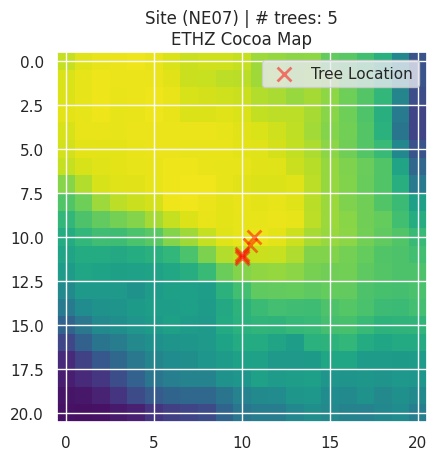

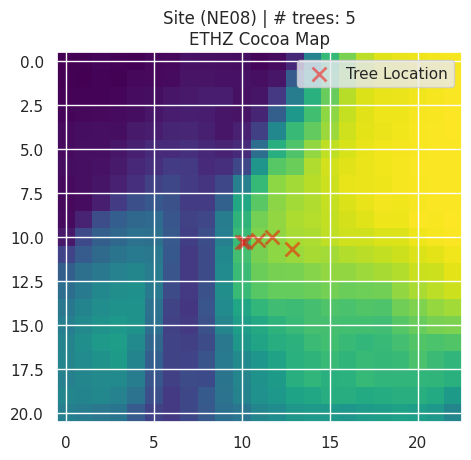

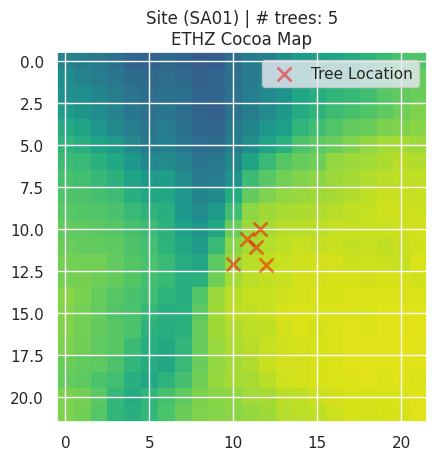

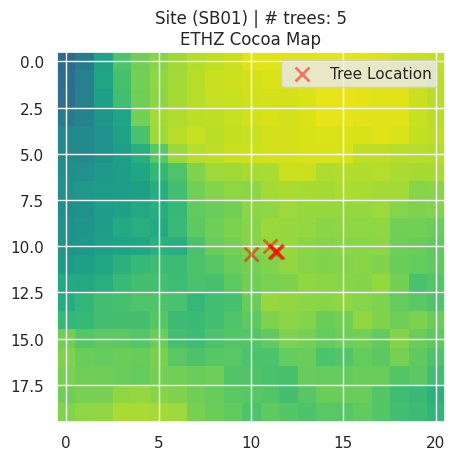

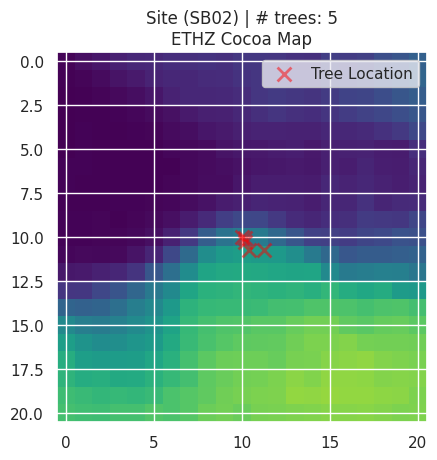

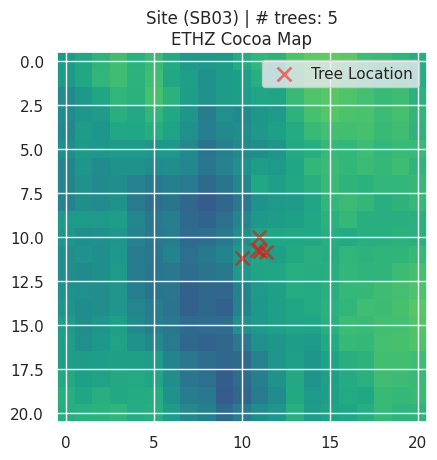

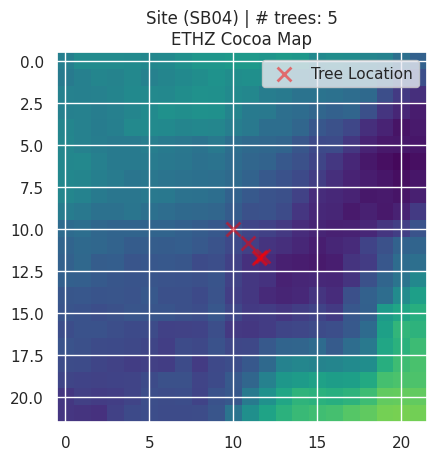

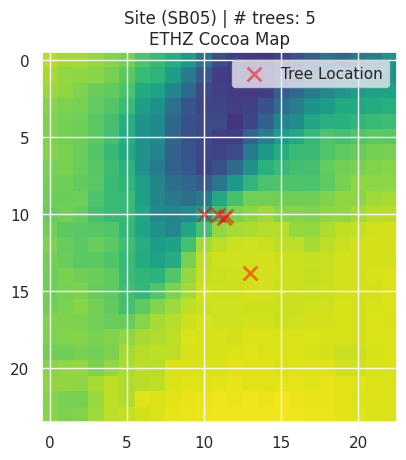

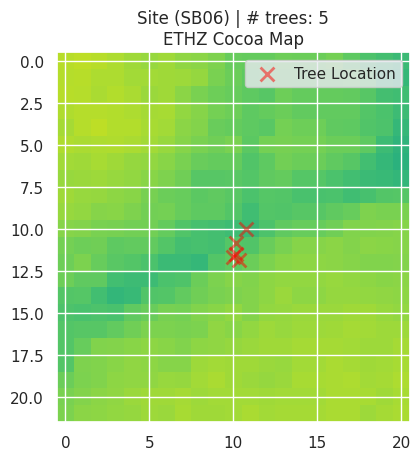

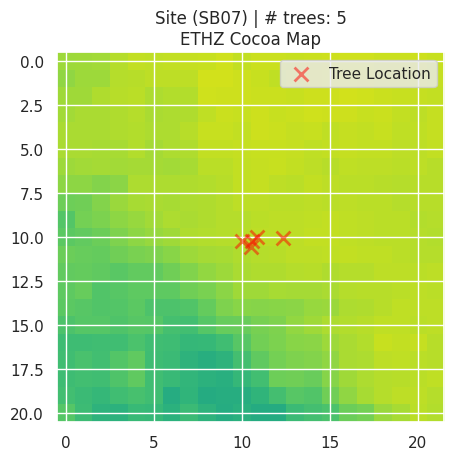

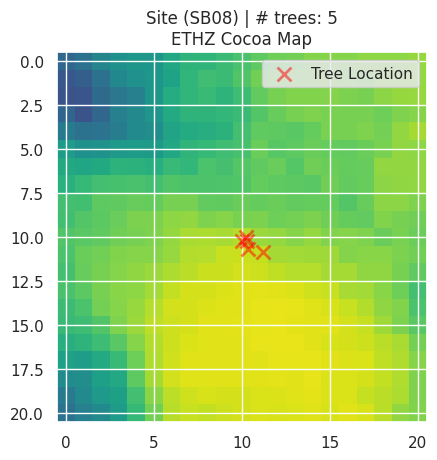

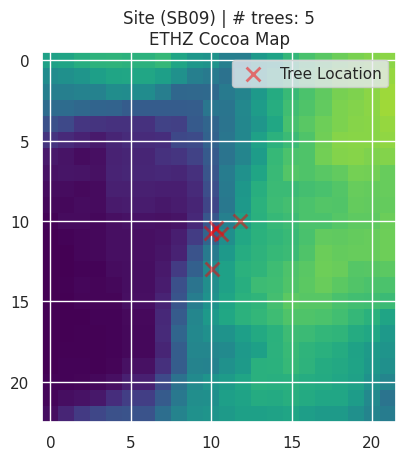

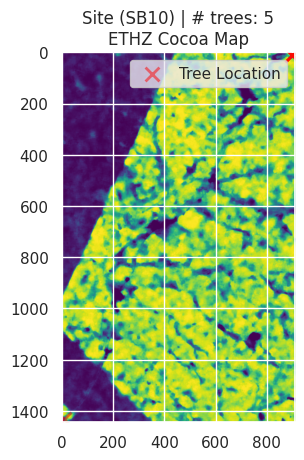

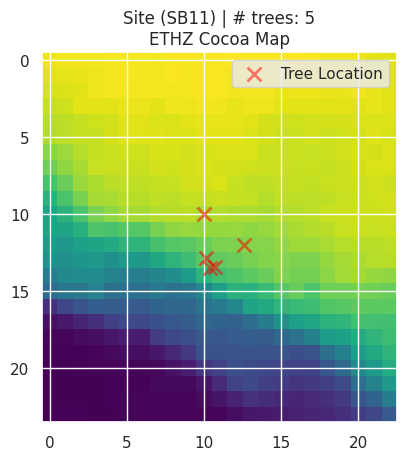

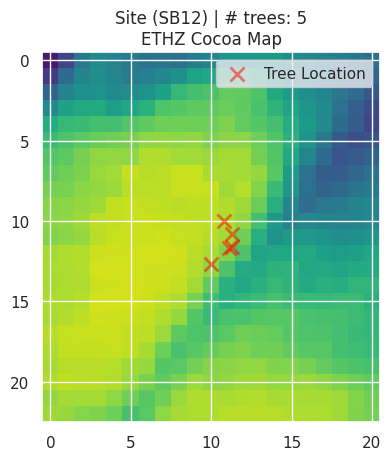

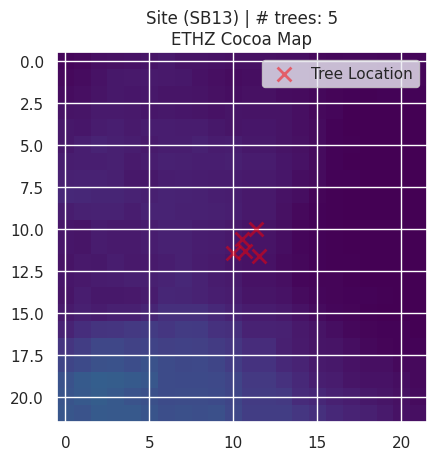

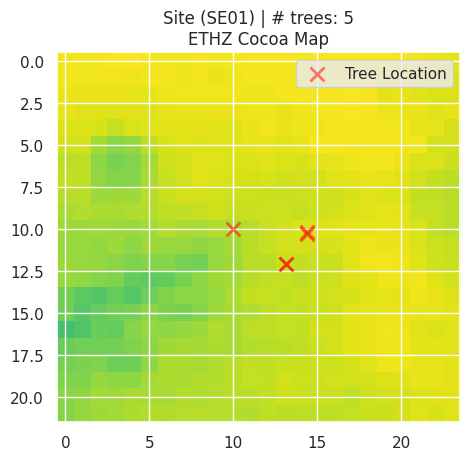

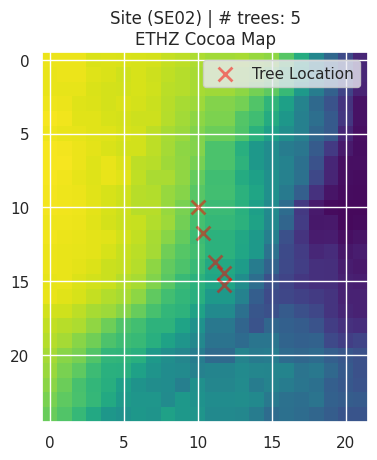

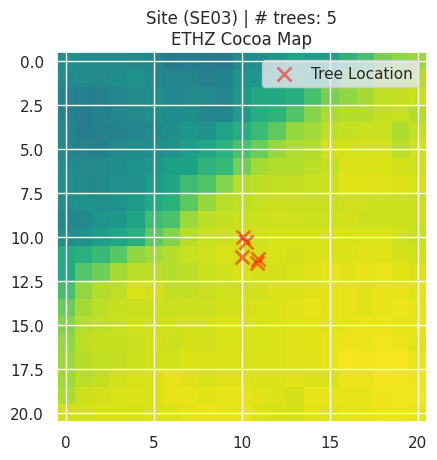

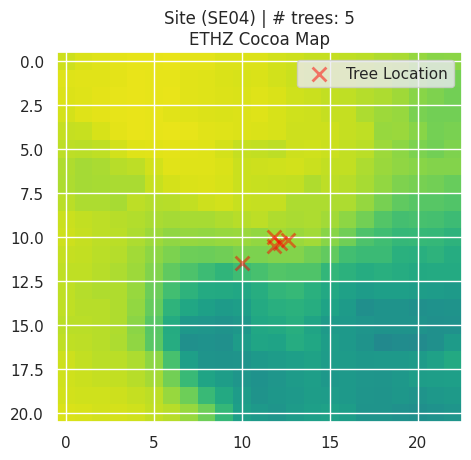

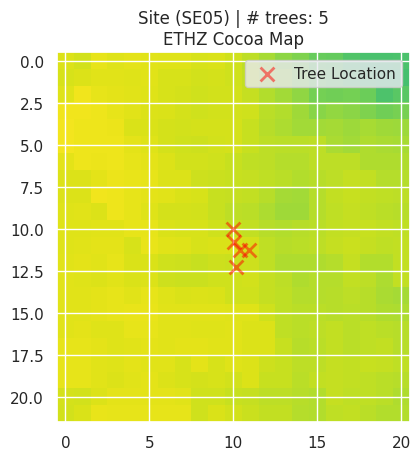

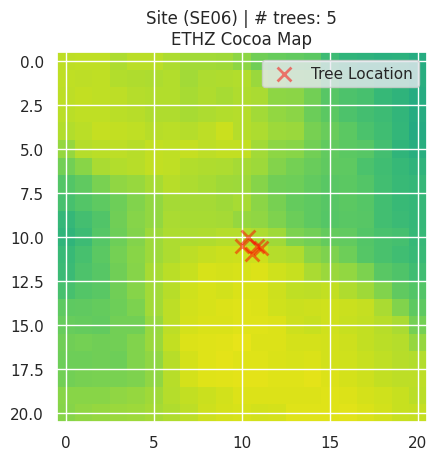

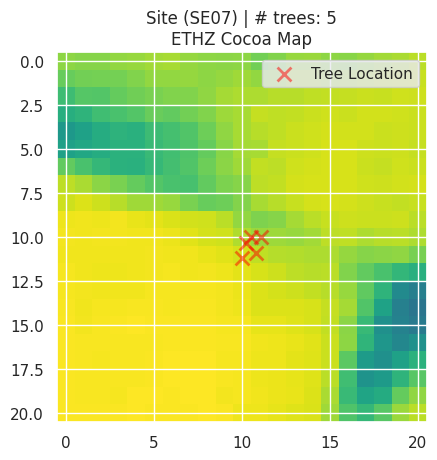

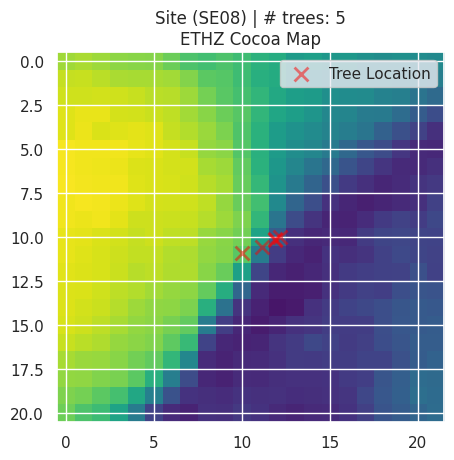

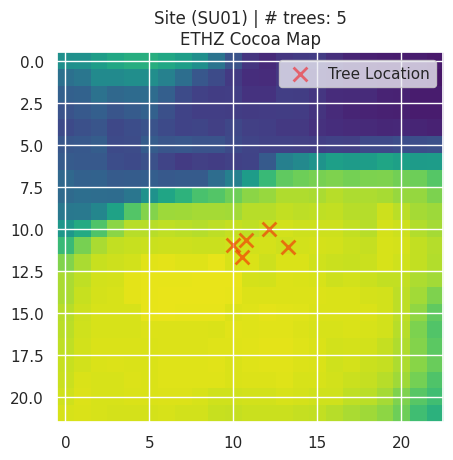

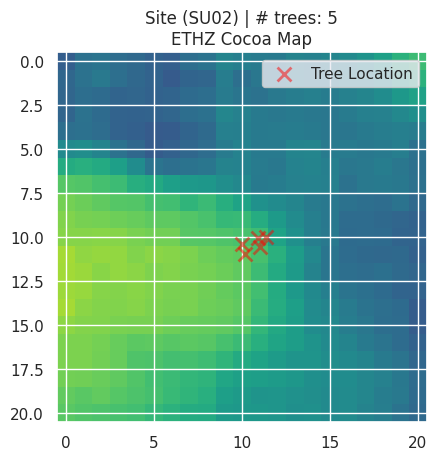

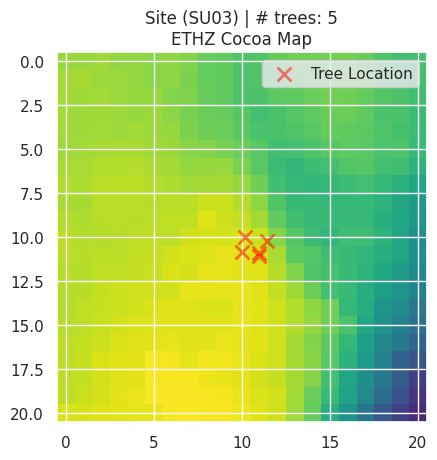

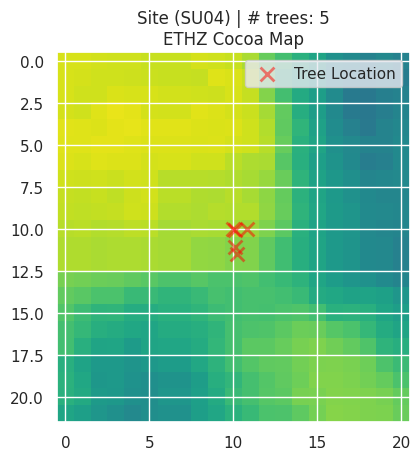

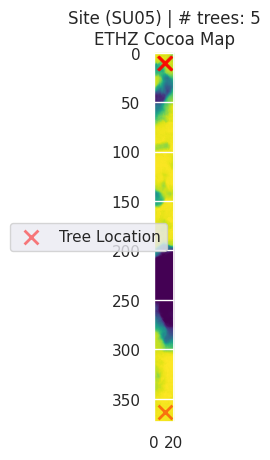

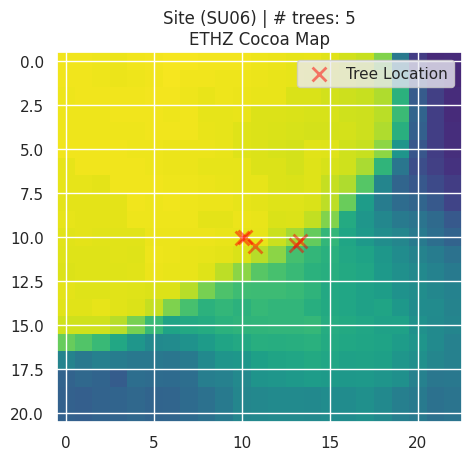

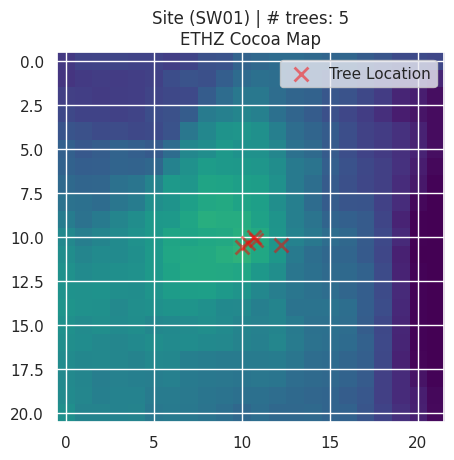

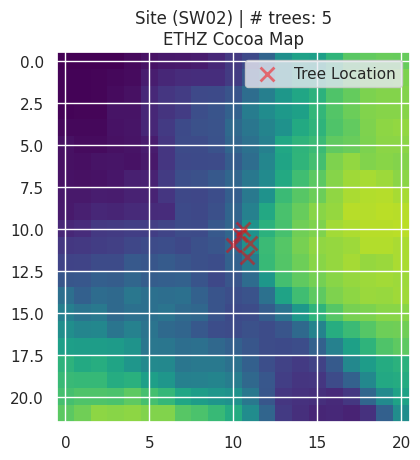

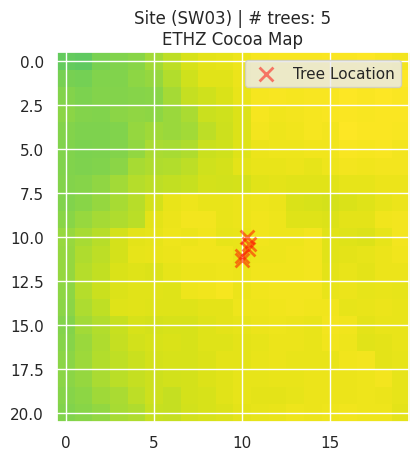

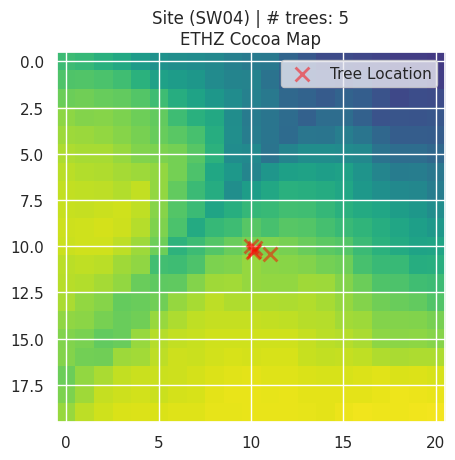

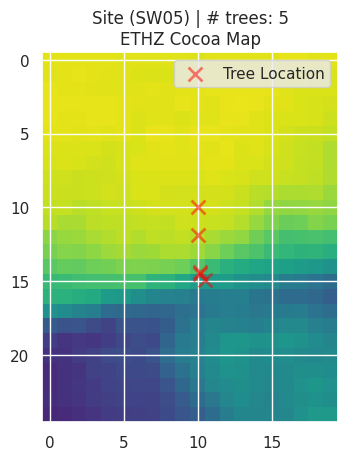

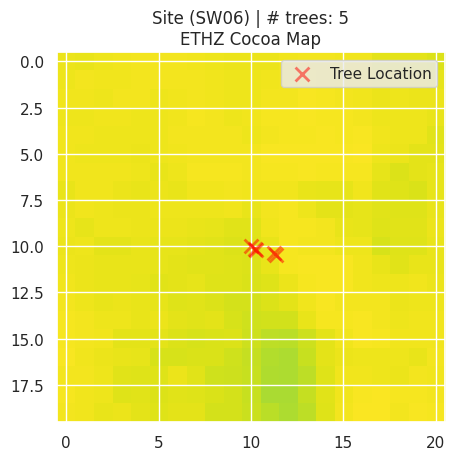

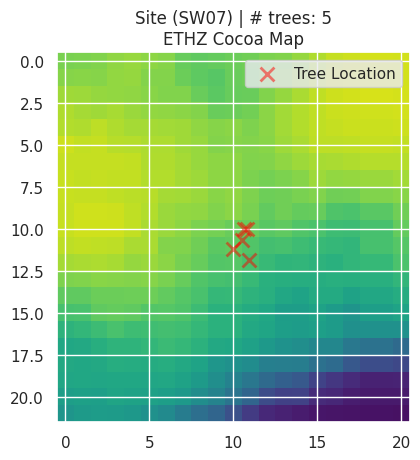

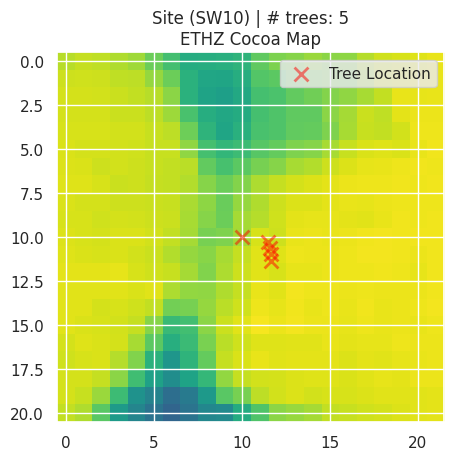

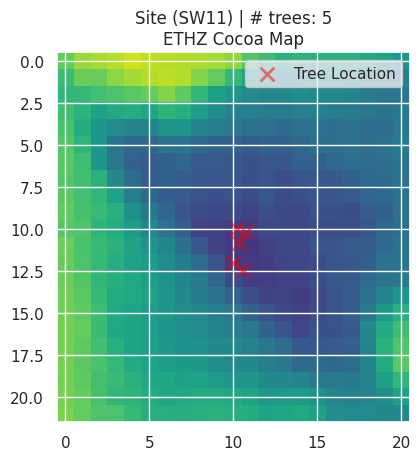

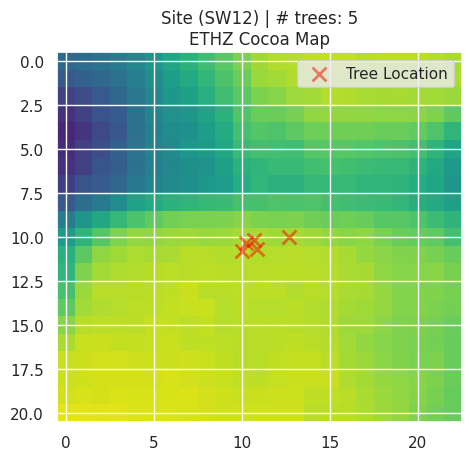

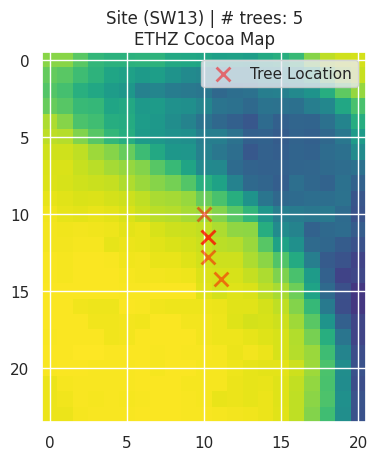

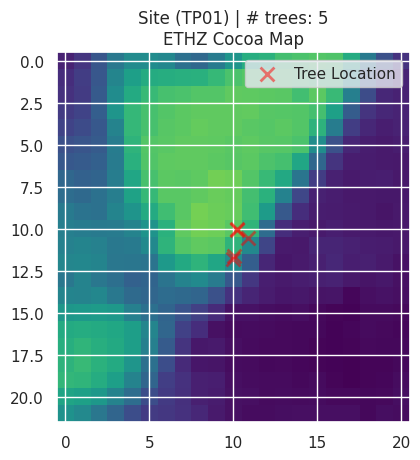

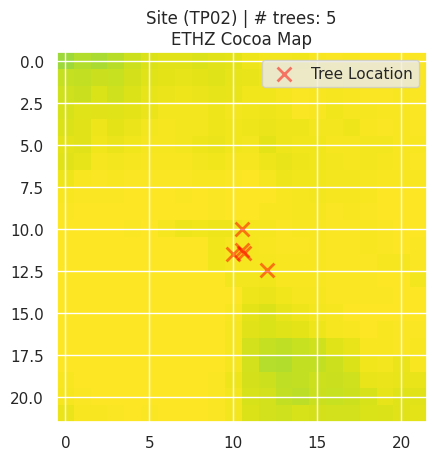

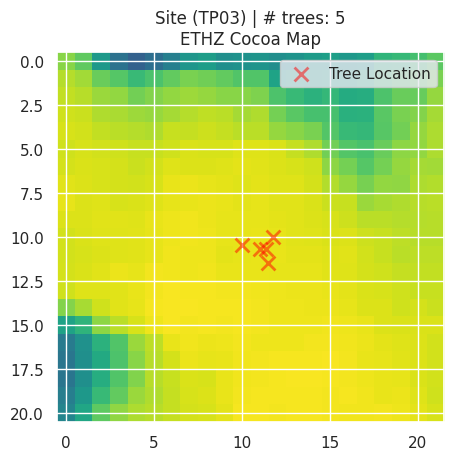

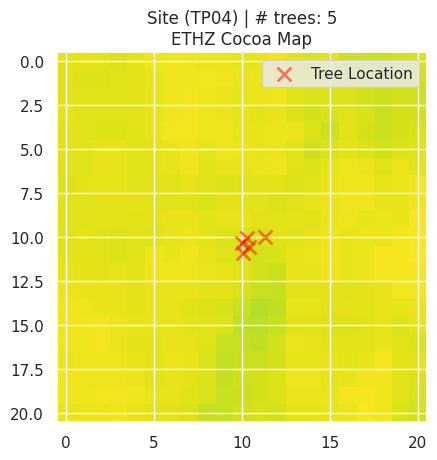

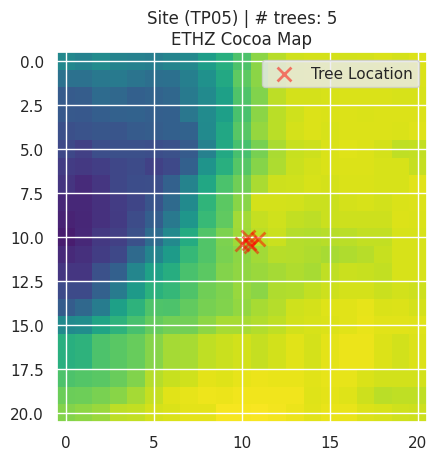

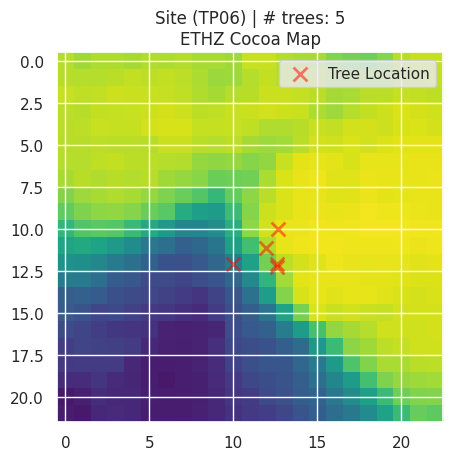

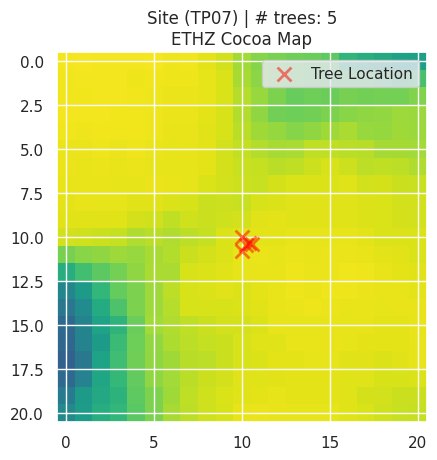

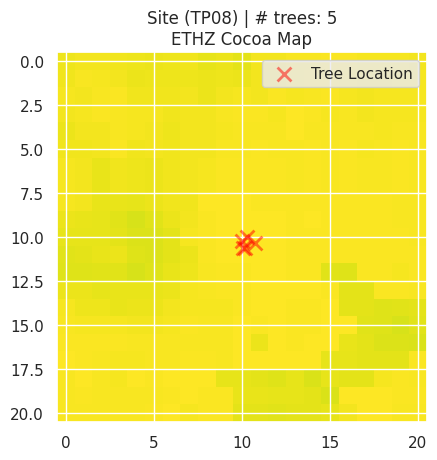

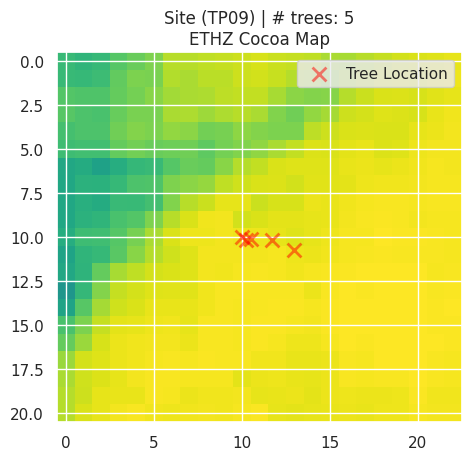

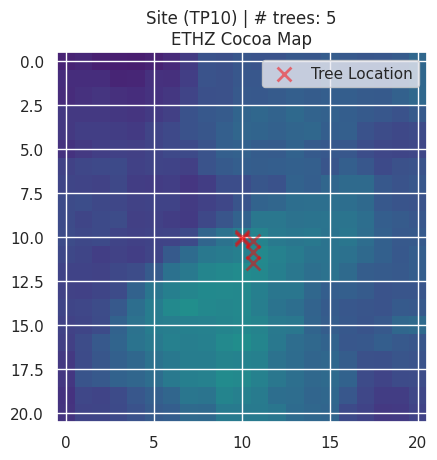

In [46]:
for s in sites:
    plot_site_over_ethz_map(s, padding_px=10)
    plt.show()